#### task 1 
--- Outlier analysis on avg_ai_adoption_rate, avg_productivity_change_percent, avg_ai_maturity_score (IQR / z-score)

In [1]:
import os

print(os.getcwd())
print(os.listdir("../data"))

C:\Users\chinn\OneDrive\Desktop\data analytics internship\AIPulse-Enterprise-AI-Adoption-Business-Performance-Analytics\notebooks
['cleaned', 'raw', 'TASK']


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
df_company = pd.read_csv("../data/raw/ai_company_adoption.csv")
df_industry = pd.read_csv("../data/raw/ai_industry_summary.csv")
df_country = pd.read_csv("../data/raw/country_ai_index.csv")

In [7]:
columns = [
    "ai_adoption_rate",
    "productivity_change_percent",
    "ai_maturity_score"
]


In [8]:
#### apply iqr
for column in columns:

    Q1 = df_company[column].quantile(0.25)
    Q3 = df_company[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - (1.5 * IQR)
    upper_limit = Q3 + (1.5 * IQR)

    outliers = df_company[
        (df_company[column] < lower_limit) |
        (df_company[column] > upper_limit)
    ]

    print("=" * 60)
    print("Column :", column)
    print("Q1 :", round(Q1,2))
    print("Q3 :", round(Q3,2))
    print("IQR :", round(IQR,2))
    print("Lower Limit :", round(lower_limit,2))
    print("Upper Limit :", round(upper_limit,2))
    print("Number of Outliers :", len(outliers))

Column : ai_adoption_rate
Q1 : 26.43
Q3 : 46.2
IQR : 19.77
Lower Limit : -3.23
Upper Limit : 75.86
Number of Outliers : 504
Column : productivity_change_percent
Q1 : 5.07
Q3 : 13.12
IQR : 8.05
Lower Limit : -7.0
Upper Limit : 25.2
Number of Outliers : 529
Column : ai_maturity_score
Q1 : 0.25
Q3 : 0.44
IQR : 0.18
Lower Limit : -0.03
Upper Limit : 0.71
Number of Outliers : 582


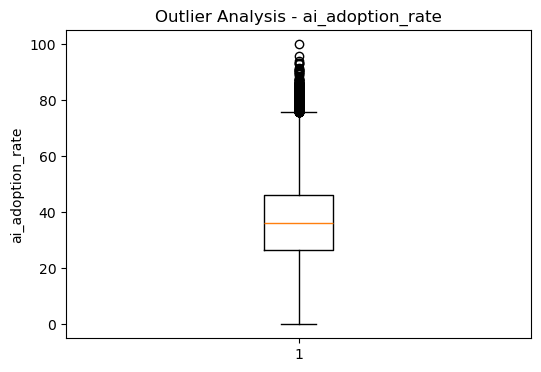

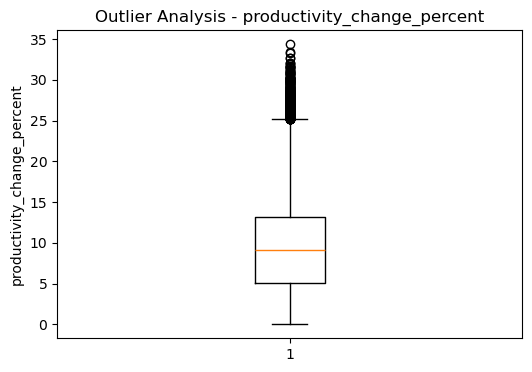

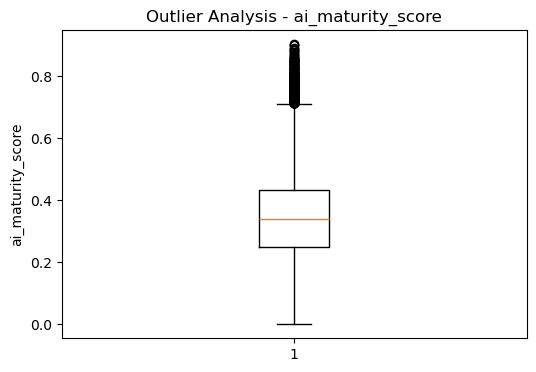

In [9]:
for column in columns:

    plt.figure(figsize=(6,4))

    plt.boxplot(df_company[column])

    plt.title(f"Outlier Analysis - {column}")

    plt.ylabel(column)

    plt.show()

##### observations
1. AI Adoption Rate
Outliers appear above approximately 76%.
You found 504 outliers.
These likely represent companies with very high AI adoption, which is realistic.
Effect: They can increase the mean, but they also highlight top-performing companies.
    
2. Productivity Change Percentage
Outliers appear above approximately 25.2%.
You found 529 outliers.
These represent companies with exceptionally high productivity improvements.
Effect: They can increase the average productivity, but they may contain valuable business insights.
    
3. AI Maturity Score
Outliers appear above approximately 0.71.
You found 582 outliers.
These indicate companies with advanced AI maturity.
Effect: They may affect the mean, but they represent organizations leading in AI adoption.

#### task 2 At least 4 charts (distribution, trend, comparison, composition)

#### Chart 1: Distribution (Histogram)

Purpose: Show how AI adoption rates are distributed.

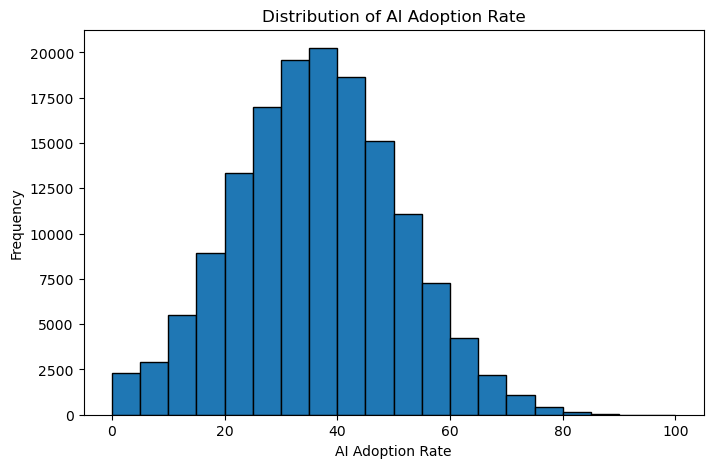

In [11]:
plt.figure(figsize=(8,5))

plt.hist(df_company["ai_adoption_rate"],
         bins=20,
         edgecolor="black")

plt.title("Distribution of AI Adoption Rate")
plt.xlabel("AI Adoption Rate")
plt.ylabel("Frequency")

plt.show()

#### Observation:

Most companies have moderate AI adoption rates, while only a few companies have very high adoption levels.

### Chart 2: Trend (Line Chart)

Purpose: Show the trend of AI adoption across survey years.

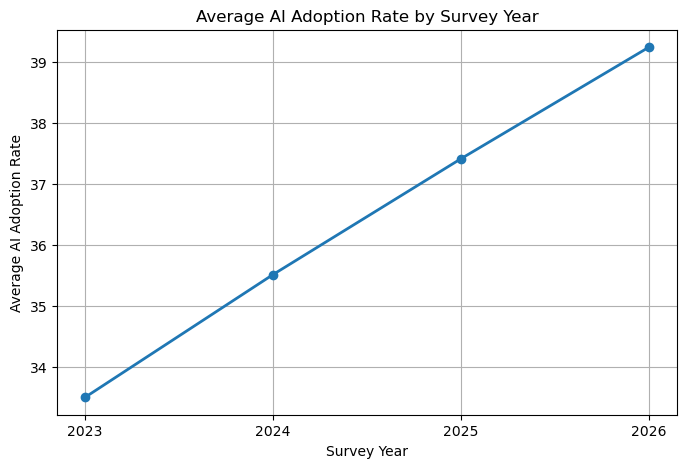

In [13]:
trend = df_company.groupby("survey_year")["ai_adoption_rate"].mean()

plt.figure(figsize=(8,5))

plt.plot(
    trend.index,
    trend.values,
    marker="o",
    linewidth=2
)

plt.xticks(trend.index)   # Show only 2023, 2024, 2025, 2026

plt.title("Average AI Adoption Rate by Survey Year")
plt.xlabel("Survey Year")
plt.ylabel("Average AI Adoption Rate")
plt.grid(True)

plt.show()

#### The line chart shows how the average AI adoption rate changes across different survey years, helping identify overall trends.

In [18]:
#### Chart 3: Comparison (Bar Chart)
### Purpose: Compare AI adoption across regions.

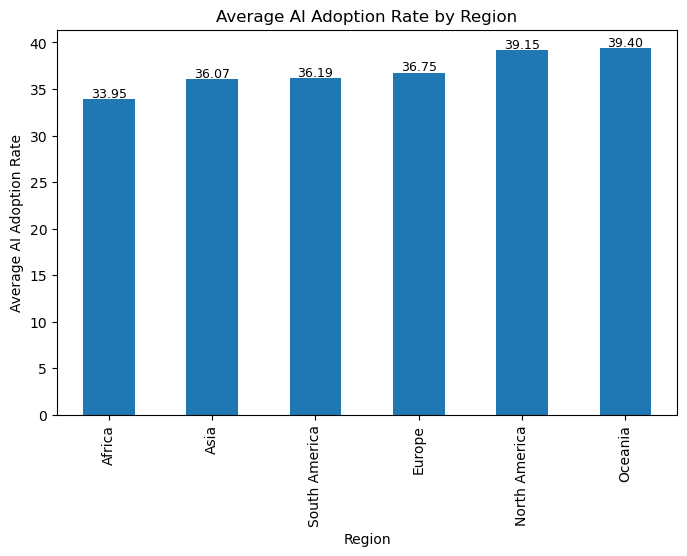

In [20]:
region_avg = df_company.groupby("region")["ai_adoption_rate"].mean().sort_values()

plt.figure(figsize=(8,5))

ax = region_avg.plot(kind="bar")

plt.title("Average AI Adoption Rate by Region")
plt.xlabel("Region")
plt.ylabel("Average AI Adoption Rate")

for i, value in enumerate(region_avg):
    plt.text(i, value + 0.2, f"{value:.2f}", ha="center", fontsize=9)

plt.show()

### observations 
The average AI adoption rate is relatively consistent across regions.
Oceania and North America have the highest average adoption rates, while Africa has the lowest. The differences are modest 
suggesting that AI adoption is fairly balanced across regions in this dataset.

In [21]:
#### Composition (Pie Chart)
### Purpose: Show the proportion of companies by industry.

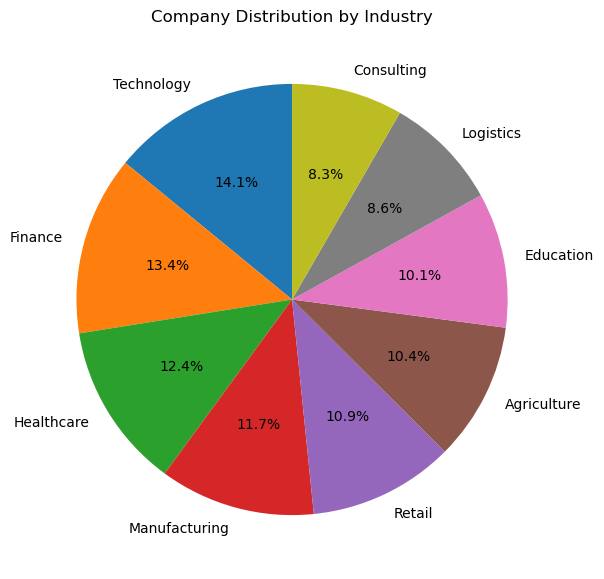

In [22]:
industry_counts = df_company["industry"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(industry_counts,
        labels=industry_counts.index,
        autopct="%1.1f%%",
        startangle=90)

plt.title("Company Distribution by Industry")

plt.show()

### Insight 1: AI Adoption is Increasing Over Time

The average AI adoption rate increased steadily from 2023 to 2026, indicating that more companies are adopting AI technologies each year.

#### Insight 2: Regional Differences in AI Adoption

Oceania and North America have the highest average AI adoption rates, while Africa has the lowest. However, the differences between regions are relatively small, suggesting AI adoption is becoming widespread across regions.

#### Insight 3: Most Companies Have Moderate AI Adoption

The distribution of AI adoption rate shows that most companies fall within the middle range, while only a small number of companies have exceptionally high adoption rates.

### Insight 4: Outliers Represent High-Performing Companies

Outlier analysis identified a small number of companies with very high AI adoption rates, productivity improvements, and AI maturity scores. Since these values are realistic and account for less than 1% of the dataset, they were retained as valid business observations.

#### Insight 5: Industry Representation is Well Distributed

The industry composition chart shows that the dataset contains companies from multiple industries, providing a balanced dataset for comparing AI adoption and business performance across sectors.